# DataLab Cup 2: CNN for Object Detection
<hr>

**Team:** 4

**Team member:** 113065703 翁嘉妤、114501538 林言蓉、114062516 李子賢

In [1]:
classes_name =  ["aeroplane", "bicycle", "bird", "boat", "bottle",
                 "bus", "car", "cat", "chair", "cow", "diningtable",
                 "dog", "horse", "motorbike", "person", "pottedplant",
                 "sheep", "sofa", "train","tvmonitor"]

In [2]:
import tensorflow as tf
import numpy as np

2025-11-07 08:06:15.398781: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-07 08:06:15.404443: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1762473975.411607 1429904 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1762473975.413815 1429904 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1762473975.419183 1429904 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [3]:
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        # Currently, memory growth needs to be the same across GPUs
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        # Select GPU number 1
        tf.config.experimental.set_visible_devices(gpus[1], 'GPU')
        logical_gpus = tf.config.experimental.list_logical_devices('GPU')
        print(len(gpus), "Physical GPUs,", len(logical_gpus), "Logical GPUs")
    except RuntimeError as e:
        # Memory growth must be set before GPUs have been initialized
        print(e)

2 Physical GPUs, 1 Logical GPUs


I0000 00:00:1762473976.621822 1429904 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 22289 MB memory:  -> device: 1, name: NVIDIA GeForce RTX 4090, pci bus id: 0000:02:00.0, compute capability: 8.9


In [4]:
# common params
IMAGE_SIZE = 448
BATCH_SIZE = 32
NUM_CLASSES = 20
MAX_OBJECTS_PER_IMAGE = 20

# dataset params
DATA_PATH = './pascal_voc_training_data.txt'
IMAGE_DIR = './VOCdevkit_train/VOC2007/JPEGImages/'

BALANCED_DATA_PATH = './pascal_voc_balanced_data.txt' 

AUG_TRAINING_IMAGE_DIR = './VOCdevkit_train_aug/VOC2007/JPEGImages/'
AUG_TRAINING_DATA_PATH = './pascal_voc_aug_data.txt'

# model params
CELL_SIZE = 7
BOXES_PER_CELL = 2
OBJECT_SCALE = 1
NOOBJECT_SCALE = 0.5
CLASS_SCALE = 1
COORD_SCALE = 5

# training params
LEARNING_RATE = 1e-5
EPOCHS = 70

## Data Imbalance

In [5]:
import collections
import matplotlib.pyplot as plt

def check_imbalance(data_file_path, class_names):
    print("Checking for data imbalance...")
    
    all_class_indices = []
    
    with open(data_file_path, 'r') as f:
        for line in f:
            line = line.strip()
            ss = line.split(' ')
            objects = [float(num) for num in ss[1:]]
            
            for i in range(4, len(objects), 5):
                class_index = int(objects[i])
                all_class_indices.append(class_index)

    class_counts = collections.Counter(all_class_indices)
    
    sorted_counts = sorted(class_counts.items())
    
    print("\n--- Class Instance Report ---")
    counts_for_weighting = []
    labels_for_plot = []
    
    for class_index, count in sorted_counts:
        class_name = class_names[class_index]
        print(f"{class_name} (ID {class_index}): {count} instances")
        counts_for_weighting.append(count)
        labels_for_plot.append(class_name)
    print("-----------------------------\n")
    
    plt.figure(figsize=(15, 7))
    plt.bar(labels_for_plot, counts_for_weighting)
    plt.title('Class Distribution in Training Data')
    plt.xlabel('Class Name')
    plt.ylabel('Number of Instances')
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

Checking for data imbalance...

--- Class Instance Report ---
aeroplane (ID 0): 331 instances
bicycle (ID 1): 417 instances
bird (ID 2): 599 instances
boat (ID 3): 398 instances
bottle (ID 4): 629 instances
bus (ID 5): 272 instances
car (ID 6): 1636 instances
cat (ID 7): 389 instances
chair (ID 8): 1425 instances
cow (ID 9): 356 instances
diningtable (ID 10): 309 instances
dog (ID 11): 536 instances
horse (ID 12): 403 instances
motorbike (ID 13): 390 instances
person (ID 14): 5392 instances
pottedplant (ID 15): 620 instances
sheep (ID 16): 353 instances
sofa (ID 17): 419 instances
train (ID 18): 328 instances
tvmonitor (ID 19): 366 instances
-----------------------------



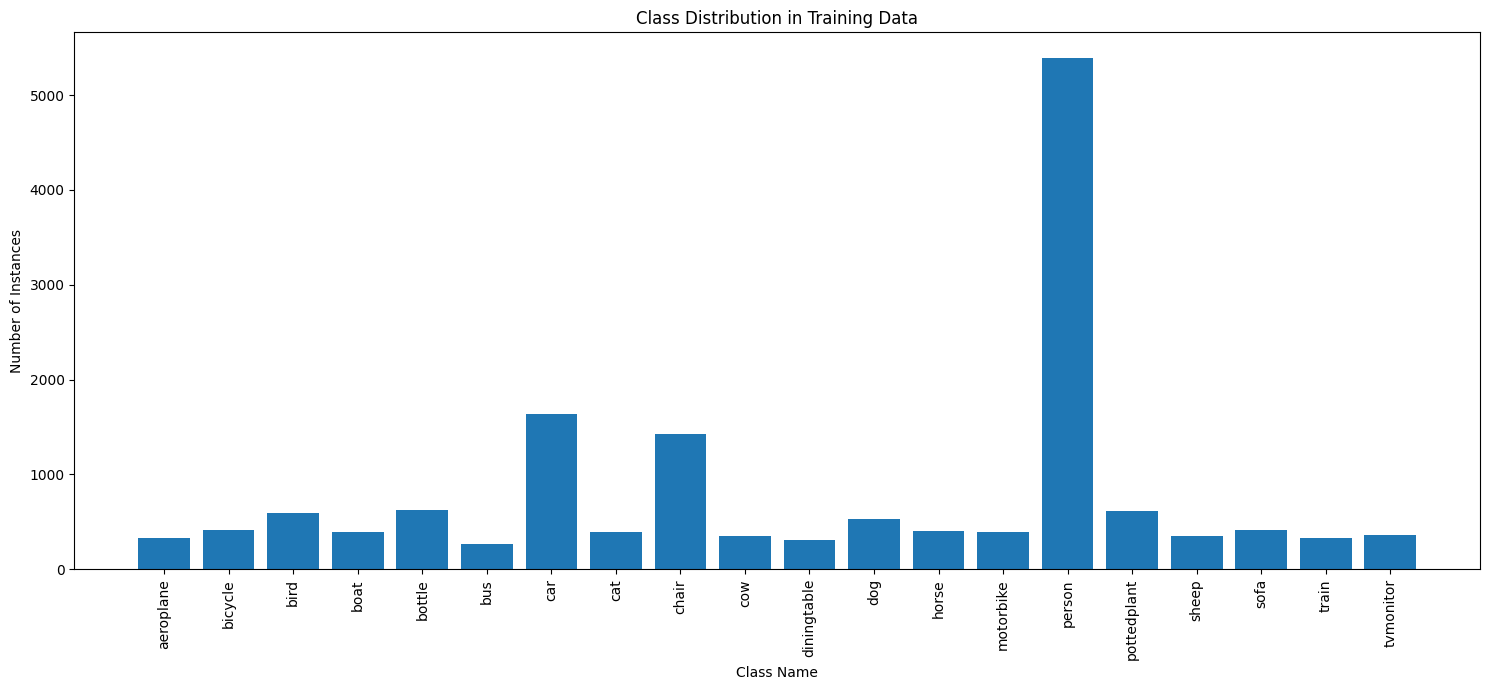

In [6]:
check_imbalance(DATA_PATH, classes_name)

Creating oversampled dataset list...
Loaded 4974 original images.
Starting oversampling loop...

--- Class Instance Report ---
aeroplane (ID 0): 2000 instances
bicycle (ID 1): 2000 instances
bird (ID 2): 2000 instances
boat (ID 3): 2001 instances
bottle (ID 4): 2004 instances
bus (ID 5): 2001 instances
car (ID 6): 2000 instances
cat (ID 7): 2001 instances
chair (ID 8): 2003 instances
cow (ID 9): 2006 instances
diningtable (ID 10): 2000 instances
dog (ID 11): 2000 instances
horse (ID 12): 2000 instances
motorbike (ID 13): 2000 instances
person (ID 14): 5392 instances
pottedplant (ID 15): 2003 instances
sheep (ID 16): 2010 instances
sofa (ID 17): 2000 instances
train (ID 18): 2000 instances
tvmonitor (ID 19): 2001 instances
-----------------------------

Oversampling complete. New dataset size: 21772


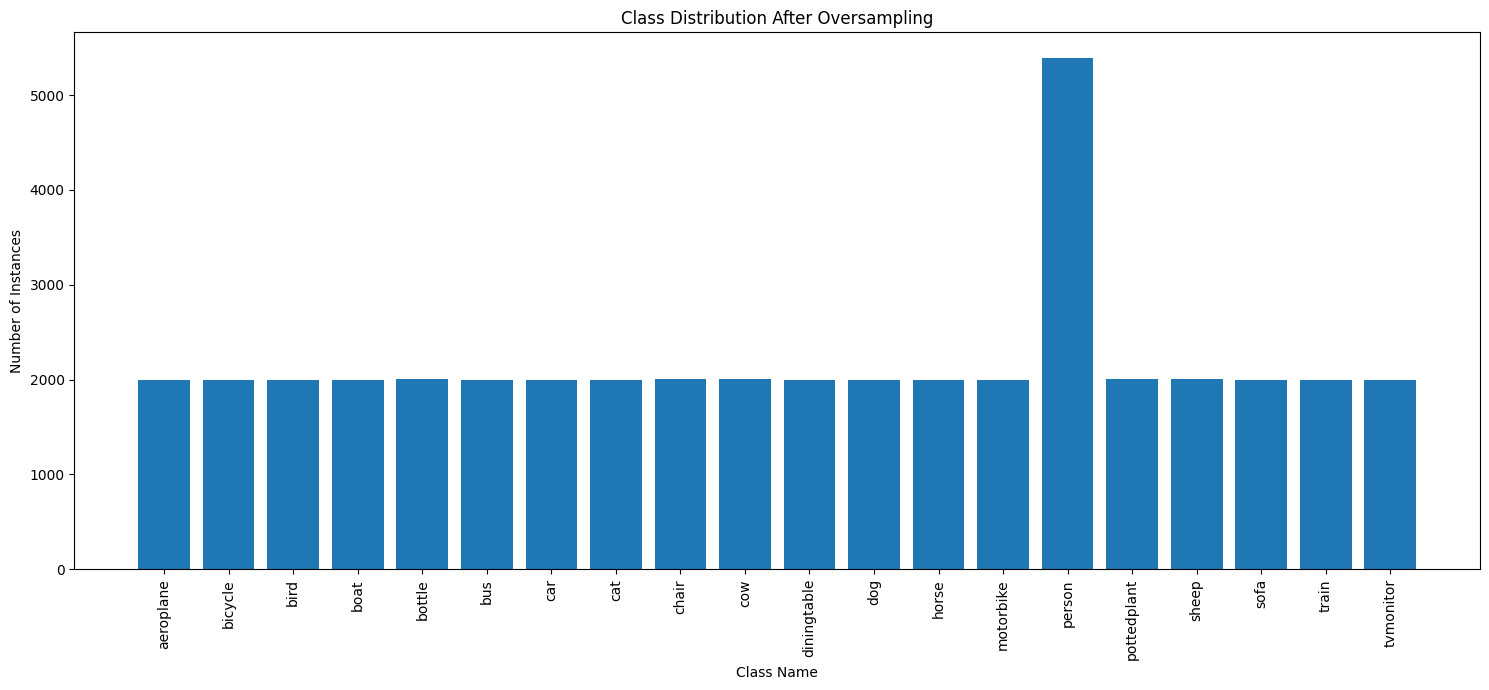


Writing balanced FILENAME LIST to ./pascal_voc_balanced_data.txt...
Successfully wrote 21772 lines to ./pascal_voc_balanced_data.txt.

Balanced data file './pascal_voc_balanced_data.txt' has been created.


In [7]:
import numpy as np
import matplotlib.pyplot as plt

AUG_LOWER_BOUND = 2000 

def create_oversampled_dataset(data_path, class_name_list, output_filename='pascal_voc_balanced_data.txt'):
    print("Creating oversampled dataset list...")
    
    image_name_list = []
    image_name_to_bboxes_dict = {} 
    object_class_list = []         
    object_num_list = []           

    with open(data_path, 'r') as fin:
        for line in fin:
            tokens = line.strip().split()
            image_name = tokens[0]
            image_name_list.append(image_name)

            records = [float(num) for num in tokens[1:]]
            
            image_name_to_bboxes_dict[image_name] = np.array(records).reshape((-1, 5))
            
            object_classes = [int(records[i]) for i in range(4, len(records), 5)]
            object_class_list.append(object_classes)
            object_num_list.append(len(records) // 5)

    print(f"Loaded {len(image_name_list)} original images.")

    aug_image_name_list = [] 
    image_count = np.zeros(len(image_name_list), int)
    class_count = np.zeros(NUM_CLASSES, int) 

    for i, image_name in enumerate(image_name_list):
        aug_image_name_list.append(f'{image_count[i]}_{image_name}')
        image_count[i] += 1
        for object_class in object_class_list[i]:
            class_count[object_class] += 1
            
    sorted_indices = np.argsort(object_num_list)[::-1]
    need_aug = np.ones(len(image_name_list), bool)

    print("Starting oversampling loop...")
    while (class_count < AUG_LOWER_BOUND).any():
        image_added_in_this_pass = False 
        for i in sorted_indices:
            if not need_aug[i]:
                continue
            
            object_classes = object_class_list[i]
            
            if not object_classes:
                need_aug[i] = False
                continue

            if (class_count[object_classes] < AUG_LOWER_BOUND).all():
                aug_image_name_list.append(f'{image_count[i]}_{image_name_list[i]}')
                image_count[i] += 1
                image_added_in_this_pass = True
                for object_class in object_classes:
                    class_count[object_class] += 1
            else:
                need_aug[i] = False
        
        if not image_added_in_this_pass:
            print("Warning: Oversampling loop finished but some classes might still be below threshold.")
            break 

    
    print("\n--- Class Instance Report ---")
    counts_for_plot = []
    labels_for_plot = []
    for i in range(NUM_CLASSES):
        class_name = class_name_list[i]
        count = class_count[i]
        print(f"{class_name} (ID {i}): {count} instances")
        counts_for_plot.append(count)
        labels_for_plot.append(class_name)
    print("-----------------------------") 
    print(f"\nOversampling complete. New dataset size: {len(aug_image_name_list)}")
    
    plt.figure(figsize=(15, 7))
    plt.bar(labels_for_plot, counts_for_plot)
    plt.title('Class Distribution After Oversampling')
    plt.xlabel('Class Name')
    plt.ylabel('Number of Instances')
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

    print(f"\nWriting balanced FILENAME LIST to {output_filename}...")
    try:
        with open(output_filename, 'w') as f_out:
            for aug_name in aug_image_name_list:
                original_name = aug_name.split('_', 1)[1]
                
                f_out.write(f"{original_name}\n")
                
        print(f"Successfully wrote {len(aug_image_name_list)} lines to {output_filename}.")
        
    except IOError as e:
        print(f"Error writing to file {output_filename}: {e}")

    return image_name_to_bboxes_dict


image_name_to_bboxes_dict = create_oversampled_dataset(DATA_PATH, classes_name, output_filename=BALANCED_DATA_PATH)
print(f"\nBalanced data file '{BALANCED_DATA_PATH}' has been created.")

## Augmentation

In [8]:
def augment_with_tf(image_tensor, bboxes):
    aug_img = tf.cast(image_tensor, tf.float32) / 255.0
    
    aug_img = tf.image.random_brightness(aug_img, max_delta=0.1) # 亮度
    aug_img = tf.image.random_contrast(aug_img, lower=0.8, upper=1.2) # 對比
    aug_img = tf.image.random_saturation(aug_img, lower=0.8, upper=1.2) # 飽和
    aug_img = tf.image.random_hue(aug_img, max_delta=0.08) # 色相
    
    aug_img = tf.clip_by_value(aug_img, 0.0, 1.0)
    
    img_shape = tf.shape(aug_img)
    img_width = tf.cast(img_shape[1], tf.float32)
    
    do_flip = tf.random.uniform(()) > 0.5
    
    aug_img = tf.cond(do_flip, 
                      lambda: tf.image.flip_left_right(aug_img), 
                      lambda: aug_img)
    
    bboxes_tensor = tf.convert_to_tensor(bboxes, dtype=tf.float32)
    xmin, ymin, xmax, ymax, class_id = tf.split(bboxes_tensor, 5, axis=1)
    
    new_xmin = tf.cond(do_flip, lambda: img_width - xmax, lambda: xmin)
    new_xmax = tf.cond(do_flip, lambda: img_width - xmin, lambda: xmax)
    
    aug_bboxes_tensor = tf.concat([new_xmin, ymin, new_xmax, ymax, class_id], axis=1)
    
    aug_img_np = (aug_img.numpy() * 255.0).astype(np.uint8)
    aug_bboxes_np = aug_bboxes_tensor.numpy()
    
    return aug_img_np, aug_bboxes_np

In [9]:
import os
import shutil

def generate_aug_dataset(image_name_to_bboxes_dict):
    print("\nStarting Offline Augmentation (Color Jitter, Flip)...")
    if os.path.exists(AUG_TRAINING_IMAGE_DIR):
        print(f"Removing old augmented image directory: {AUG_TRAINING_IMAGE_DIR}")
        shutil.rmtree(AUG_TRAINING_IMAGE_DIR)
    
    print(f"Creating new augmented image directory: {AUG_TRAINING_IMAGE_DIR}")
    os.makedirs(AUG_TRAINING_IMAGE_DIR, exist_ok=True) 

    print(f"Reading balanced list from: {BALANCED_DATA_PATH}")
    print(f"Writing final augmented annotations to: {AUG_TRAINING_DATA_PATH}")

    seen_counts = {} 
    
    try:
        with open(BALANCED_DATA_PATH, 'r') as f_in, \
             open(AUG_TRAINING_DATA_PATH, 'w', newline='\n') as f_out:
            
            lines = f_in.readlines()
            total_images = len(lines)
            
            for i, line in enumerate(lines):
                if (i+1) % 500 == 0:
                    print(f"Processing image {i+1}/{total_images}...")
                
                image_name = line.strip()
                if not image_name:
                    continue
                
                count = seen_counts.get(image_name, 0)
                aug_image_name = f"{count}_{image_name}" 
                seen_counts[image_name] = count + 1

                img_file = tf.io.read_file(os.path.join(IMAGE_DIR, image_name))
                img_tensor = tf.io.decode_jpeg(img_file, channels=3) 
                bboxes = image_name_to_bboxes_dict.get(image_name)

                if count == 0:
                    aug_img_np = img_tensor.numpy() 
                    aug_bboxes_np = bboxes.copy()
                else:
                    aug_img_np, aug_bboxes_np = augment_with_tf(img_tensor, bboxes.copy())
                
                img_jpeg = tf.io.encode_jpeg(aug_img_np)
                tf.io.write_file(os.path.join(AUG_TRAINING_IMAGE_DIR, aug_image_name), img_jpeg)
                
                record = [aug_image_name] + [str(b) for box in aug_bboxes_np for b in box]
                f_out.write(' '.join(record) + '\n')
                
        print(f"Offline augmentation complete. {total_images} images generated.")
    
    except FileNotFoundError:
        print(f"Error: Could not find {BALANCED_DATA_PATH}. Did create_oversampled_dataset() run correctly?")
    except Exception as e:
        print(f"An error occurred during augmentation: {e}")

generate_aug_dataset(image_name_to_bboxes_dict)


Starting Offline Augmentation (Color Jitter, Flip)...
Removing old augmented image directory: ./VOCdevkit_train_aug/VOC2007/JPEGImages/
Creating new augmented image directory: ./VOCdevkit_train_aug/VOC2007/JPEGImages/
Reading balanced list from: ./pascal_voc_balanced_data.txt
Writing final augmented annotations to: ./pascal_voc_aug_data.txt
Processing image 500/21772...
Processing image 1000/21772...
Processing image 1500/21772...
Processing image 2000/21772...
Processing image 2500/21772...
Processing image 3000/21772...
Processing image 3500/21772...
Processing image 4000/21772...
Processing image 4500/21772...
Processing image 5000/21772...
Processing image 5500/21772...
Processing image 6000/21772...
Processing image 6500/21772...
Processing image 7000/21772...
Processing image 7500/21772...
Processing image 8000/21772...
Processing image 8500/21772...
Processing image 9000/21772...
Processing image 9500/21772...
Processing image 10000/21772...
Processing image 10500/21772...
Proc

In [10]:
class DatasetGenerator:
    """
    Load pascalVOC 2007 dataset and creates an input pipeline.
    - Reshapes images into 448 x 448
    - converts [0 1] to [-1 1]
    - shuffles the input
    - builds batches
    """

    def __init__(self):
        self.image_names = []
        self.record_list = []
        self.object_num_list = []
        # filling the record_list
        input_file = open(AUG_TRAINING_DATA_PATH, 'r')

        for line in input_file:
            line = line.strip()
            ss = line.split(' ')
            self.image_names.append(ss[0])

            self.record_list.append([float(num) for num in ss[1:]])

            self.object_num_list.append(min(len(self.record_list[-1])//5,
                                            MAX_OBJECTS_PER_IMAGE))
            if len(self.record_list[-1]) < MAX_OBJECTS_PER_IMAGE*5:
                # if there are objects less than MAX_OBJECTS_PER_IMAGE, pad the list
                self.record_list[-1] = self.record_list[-1] +\
                [0., 0., 0., 0., 0.]*\
                (MAX_OBJECTS_PER_IMAGE-len(self.record_list[-1])//5)

            elif len(self.record_list[-1]) > MAX_OBJECTS_PER_IMAGE*5:
               # if there are objects more than MAX_OBJECTS_PER_IMAGE, crop the list
                self.record_list[-1] = self.record_list[-1][:MAX_OBJECTS_PER_IMAGE*5]

    def _data_preprocess(self, image_name, raw_labels, object_num):
        image_file = tf.io.read_file(AUG_TRAINING_IMAGE_DIR+image_name)
        image = tf.io.decode_jpeg(image_file, channels=3)

        h = tf.shape(image)[0]
        w = tf.shape(image)[1]

        width_ratio  = IMAGE_SIZE * 1.0 / tf.cast(w, tf.float32)
        height_ratio = IMAGE_SIZE * 1.0 / tf.cast(h, tf.float32)

        image = tf.image.resize(image, size=[IMAGE_SIZE, IMAGE_SIZE])
        image = (image/255) * 2 - 1

        raw_labels = tf.cast(tf.reshape(raw_labels, [-1, 5]), tf.float32)

        xmin = raw_labels[:, 0]
        ymin = raw_labels[:, 1]
        xmax = raw_labels[:, 2]
        ymax = raw_labels[:, 3]
        class_num = raw_labels[:, 4]

        xcenter = (xmin + xmax) * 1.0 / 2.0 * width_ratio
        ycenter = (ymin + ymax) * 1.0 / 2.0 * height_ratio

        box_w = (xmax - xmin) * width_ratio
        box_h = (ymax - ymin) * height_ratio

        labels = tf.stack([xcenter, ycenter, box_w, box_h, class_num], axis=1)

        return image, labels, tf.cast(object_num, tf.int32)

    def generate(self):
        dataset = tf.data.Dataset.from_tensor_slices((self.image_names,
                                                      np.array(self.record_list),
                                                      np.array(self.object_num_list)))
        dataset = dataset.shuffle(100000)
        dataset = dataset.map(self._data_preprocess,
                              num_parallel_calls = tf.data.experimental.AUTOTUNE)
        dataset = dataset.batch(BATCH_SIZE, drop_remainder=True)
        dataset = dataset.prefetch(buffer_size=200)

        return dataset

## YOLOv1


In [ ]:
from tensorflow.keras import layers

def conv_leaky_relu(inputs, filters, size, stride):
    x = layers.Conv2D(filters, size, stride, padding='same')(inputs)
    x = layers.LeakyReLU(0.1)(x)
    x = layers.BatchNormalization()(x)
    return x

In [ ]:
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications.densenet import DenseNet121, preprocess_input

img_inputs = keras.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3))

x_denorm = layers.Lambda(lambda t: (t + 1.0) * 127.5)(img_inputs)
x_preprocessed = layers.Lambda(preprocess_input, name='densenet_preprocessing')(x_denorm)

base_model = DenseNet121(weights='imagenet',
                         include_top=False,
                         input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3))

# base_model.trainable = False
for layer in base_model.layers[:-100]:
    layer.trainable = False
for layer in base_model.layers[-100:]:
    layer.trainable = True

x = base_model(x_preprocessed)

x = conv_leaky_relu(x, 512, 1, 1)   
x = conv_leaky_relu(x, 1024, 3, 1)
x = conv_leaky_relu(x, 512, 1, 1)
x = conv_leaky_relu(x, 1024, 3, 1)
x = conv_leaky_relu(x, 1024, 3, 1)
x = conv_leaky_relu(x, 1024, 3, 2) 
x = conv_leaky_relu(x, 1024, 3, 1)
x = conv_leaky_relu(x, 1024, 3, 1)

x = layers.Flatten()(x)
x = layers.Dense(1470)(x)

x = layers.LeakyReLU(0.1)(x)
outputs = layers.Dense(1470)(x)

YOLO = keras.Model(inputs=img_inputs, outputs=outputs, name="YOLO_DenseNet121")
YOLO.summary()

Model: "YOLO_DenseNet121"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 448, 448, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 448, 448, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet_preprocessing (Lambda) │ (None, 448, 448, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 14, 14, 1024)   │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 14, 14, 512)    │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 14, 14, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 1024)   │     4,719,616 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 14, 14, 1024)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 1024)   │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 512)    │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 1024)   │     4,719,616 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 14, 14, 1024)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 14, 14, 1024)   │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 14, 14, 1024)   │     9,438,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 14, 14, 1024)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 14, 14, 1024)   │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 7, 7, 1024)     │     9,438,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 7, 7, 1024)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 7, 7, 1024)     │         4,096 │
│ (BatchNormalization)            │                        │             

 Total params: 131,230,400 (500.60 MB)

 Trainable params: 126,127,168 (481.14 MB)

 Non-trainable params: 5,103,232 (19.47 MB)

In [14]:
# base boxes (for loss calculation)
base_boxes = np.zeros([CELL_SIZE, CELL_SIZE, 4])

# initializtion for each cell
for y in range(CELL_SIZE):
    for x in range(CELL_SIZE):
        base_boxes[y, x, :] = [IMAGE_SIZE / CELL_SIZE * x,
                               IMAGE_SIZE / CELL_SIZE * y, 0, 0]

base_boxes = np.resize(base_boxes, [CELL_SIZE, CELL_SIZE, 1, 4])
base_boxes = np.tile(base_boxes, [1, 1, BOXES_PER_CELL, 1])

In [ ]:
def compute_obj_loss_for_batch_one(predict, labels, object_num):
    labels = labels[:object_num]                      # shape [N, 5]
    return tf.reduce_sum(tf.map_fn(
        lambda l: losses_calculation(predict, l),
        labels,
        dtype=tf.float32
    ))

def yolo_loss(predicts, labels, objects_num):
    return tf.reduce_mean(tf.map_fn(
        lambda x: compute_obj_loss_for_batch_one(x[0], x[1], x[2]),
        (predicts, labels, objects_num),
        dtype=tf.float32
    ))

In [16]:
def iou(boxes1, boxes2):
    """calculate ious
    Args:
      boxes1: 4-D tensor [CELL_SIZE, CELL_SIZE, BOXES_PER_CELL, 4]  ====> (x_center, y_center, w, h)
      boxes2: 1-D tensor [4] ===> (x_center, y_center, w, h)

    Return:
      iou: 3-D tensor [CELL_SIZE, CELL_SIZE, BOXES_PER_CELL]
      ====> iou score for each cell
    """

    #boxes1 : [4(xmin, ymin, xmax, ymax), cell_size, cell_size, boxes_per_cell]
    boxes1 = tf.stack([boxes1[:, :, :, 0] - boxes1[:, :, :, 2] / 2, boxes1[:, :, :, 1] - boxes1[:, :, :, 3] / 2,
                      boxes1[:, :, :, 0] + boxes1[:, :, :, 2] / 2, boxes1[:, :, :, 1] + boxes1[:, :, :, 3] / 2])

    #boxes1 : [cell_size, cell_size, boxes_per_cell, 4(xmin, ymin, xmax, ymax)]
    boxes1 = tf.transpose(boxes1, [1, 2, 3, 0])

    boxes2 =  tf.stack([boxes2[0] - boxes2[2] / 2, boxes2[1] - boxes2[3] / 2,
                      boxes2[0] + boxes2[2] / 2, boxes2[1] + boxes2[3] / 2])

    #calculate the left up point of boxes' overlap area
    lu = tf.maximum(boxes1[:, :, :, 0:2], boxes2[0:2])
    #calculate the right down point of boxes overlap area
    rd = tf.minimum(boxes1[:, :, :, 2:], boxes2[2:])

    #intersection
    intersection = rd - lu

    #the size of the intersection area
    inter_square = intersection[:, :, :, 0] * intersection[:, :, :, 1]

    mask = tf.cast(intersection[:, :, :, 0] > 0, tf.float32) * tf.cast(intersection[:, :, :, 1] > 0, tf.float32)

    #if intersection is negative, then the boxes don't overlap
    inter_square = mask * inter_square

    #calculate the boxs1 square and boxs2 square
    square1 = (boxes1[:, :, :, 2] - boxes1[:, :, :, 0]) * (boxes1[:, :, :, 3] - boxes1[:, :, :, 1])
    square2 = (boxes2[2] - boxes2[0]) * (boxes2[3] - boxes2[1])

    return inter_square/(square1 + square2 - inter_square + 1e-6)

@tf.function
def losses_calculation(predict, label):
    """
    calculate loss
    Args:
      predict: 3-D tensor [cell_size, cell_size, num_classes + 5 * boxes_per_cell]
      label : [1, 5]  (x_center, y_center, w, h, class)
    """
    label = tf.reshape(label, [-1])

    #Step A. calculate objects tensor [CELL_SIZE, CELL_SIZE]
    #turn pixel position into cell position (corner)
    min_x = (label[0] - label[2] / 2) / (IMAGE_SIZE / CELL_SIZE)
    max_x = (label[0] + label[2] / 2) / (IMAGE_SIZE / CELL_SIZE)

    min_y = (label[1] - label[3] / 2) / (IMAGE_SIZE / CELL_SIZE)
    max_y = (label[1] + label[3] / 2) / (IMAGE_SIZE / CELL_SIZE)

    min_x = tf.floor(min_x)
    min_y = tf.floor(min_y)

    max_x = tf.minimum(tf.math.ceil(max_x), CELL_SIZE)
    max_y = tf.minimum(tf.math.ceil(max_y), CELL_SIZE)

    #calculate mask of object with cells
    onset = tf.cast(tf.stack([max_y - min_y, max_x - min_x]), dtype=tf.int32)
    object_mask = tf.ones(onset, tf.float32)

    offset = tf.cast(tf.stack([min_y, CELL_SIZE - max_y, min_x, CELL_SIZE - max_x]), tf.int32)
    offset = tf.reshape(offset, (2, 2))
    object_mask = tf.pad(object_mask, offset, "CONSTANT")

    #Step B. calculate the coordination of object center and the corresponding mask
    #turn pixel position into cell position (center)
    center_x = label[0] / (IMAGE_SIZE / CELL_SIZE)
    center_x = tf.floor(center_x)

    center_y = label[1] / (IMAGE_SIZE / CELL_SIZE)
    center_y = tf.floor(center_y)

    response = tf.ones([1, 1], tf.float32)

    #calculate the coordination of object center with cells
    objects_center_coord = tf.cast(tf.stack([center_y, CELL_SIZE - center_y - 1,
                             center_x, CELL_SIZE - center_x - 1]),
                             tf.int32)
    objects_center_coord = tf.reshape(objects_center_coord, (2, 2))

    #make mask
    response = tf.pad(response, objects_center_coord, "CONSTANT")

    #Step C. calculate iou_predict_truth [CELL_SIZE, CELL_SIZE, BOXES_PER_CELL]
    predict_boxes = predict[:, :, NUM_CLASSES + BOXES_PER_CELL:]

    predict_boxes = tf.reshape(predict_boxes, [CELL_SIZE,
                                               CELL_SIZE,
                                               BOXES_PER_CELL, 4])
    #cell position to pixel position
    predict_boxes = predict_boxes * [IMAGE_SIZE / CELL_SIZE,
                                     IMAGE_SIZE / CELL_SIZE,
                                     IMAGE_SIZE, IMAGE_SIZE]

    #if there's no predict_box in that cell, then the base_boxes will be calcuated with label and got iou equals 0
    predict_boxes = base_boxes + predict_boxes

    iou_predict_truth = iou(predict_boxes, label[0:4])

    #calculate C tensor [CELL_SIZE, CELL_SIZE, BOXES_PER_CELL]
    C = iou_predict_truth * tf.reshape(response, [CELL_SIZE, CELL_SIZE, 1])

    #calculate I tensor [CELL_SIZE, CELL_SIZE, BOXES_PER_CELL]
    I = iou_predict_truth * tf.reshape(response, [CELL_SIZE, CELL_SIZE, 1])

    max_I = tf.reduce_max(I, 2, keepdims=True)

    #replace large iou scores with response (object center) value
    I = tf.cast((I >= max_I), tf.float32) * tf.reshape(response, (CELL_SIZE, CELL_SIZE, 1))

    #calculate no_I tensor [CELL_SIZE, CELL_SIZE, BOXES_PER_CELL]
    no_I = tf.ones_like(I, dtype=tf.float32) - I

    p_C = predict[:, :, NUM_CLASSES:NUM_CLASSES + BOXES_PER_CELL]

    #calculate truth x, y, sqrt_w, sqrt_h 0-D
    x = label[0]
    y = label[1]

    sqrt_w = tf.sqrt(tf.abs(label[2]))
    sqrt_h = tf.sqrt(tf.abs(label[3]))

    #calculate predict p_x, p_y, p_sqrt_w, p_sqrt_h 3-D [CELL_SIZE, CELL_SIZE, BOXES_PER_CELL]
    p_x = predict_boxes[:, :, :, 0]
    p_y = predict_boxes[:, :, :, 1]

    # p_sqrt_w = tf.sqrt(tf.minimum(IMAGE_SIZE * 1.0, tf.maximum(0.0, predict_boxes[:, :, :, 2])))
    # p_sqrt_h = tf.sqrt(tf.minimum(IMAGE_SIZE * 1.0, tf.maximum(0.0, predict_boxes[:, :, :, 3])))
    epsilon = 1e-6 
    p_sqrt_w = tf.sqrt(tf.minimum(IMAGE_SIZE * 1.0, tf.maximum(epsilon, predict_boxes[:, :, :, 2])))
    p_sqrt_h = tf.sqrt(tf.minimum(IMAGE_SIZE * 1.0, tf.maximum(epsilon, predict_boxes[:, :, :, 3])))

    #calculate ground truth p 1-D tensor [NUM_CLASSES]
    P = tf.one_hot(tf.cast(label[4], tf.int32), NUM_CLASSES, dtype=tf.float32)

    #calculate predicted p_P 3-D tensor [CELL_SIZE, CELL_SIZE, NUM_CLASSES]
    p_P = predict[:, :, 0:NUM_CLASSES]

    #class_loss
    # class_loss = tf.nn.l2_loss(tf.reshape(object_mask, (CELL_SIZE, CELL_SIZE, 1)) * (p_P - P)) * CLASS_SCALE
    class_loss = tf.nn.l2_loss(tf.reshape(response, (CELL_SIZE, CELL_SIZE, 1)) * (p_P - P)) * CLASS_SCALE


    #object_loss
    object_loss = tf.nn.l2_loss(I * (p_C - C)) * OBJECT_SCALE

    #noobject_loss
    noobject_loss = tf.nn.l2_loss(no_I * (p_C)) * NOOBJECT_SCALE

    #coord_loss
    coord_loss = (tf.nn.l2_loss(I * (p_x - x)/(IMAGE_SIZE/CELL_SIZE)) +
                  tf.nn.l2_loss(I * (p_y - y)/(IMAGE_SIZE/CELL_SIZE)) +
                  tf.nn.l2_loss(I * (p_sqrt_w - sqrt_w))/IMAGE_SIZE +
                  tf.nn.l2_loss(I * (p_sqrt_h - sqrt_h))/IMAGE_SIZE) * COORD_SCALE

    return class_loss + object_loss + noobject_loss + coord_loss

In [17]:
dataset = DatasetGenerator().generate()

In [18]:
initial_lr = 1e-4
lr_after_20 = 3e-5
steps_per_epoch = len(dataset)

class WarmDownLR(tf.keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self):
        super().__init__()

    def __call__(self, step):
        epoch = step // steps_per_epoch
        return tf.cond(
            epoch < 20,
            lambda: initial_lr,
            lambda: lr_after_20
        )

In [19]:
from keras.optimizers import AdamW

optimizer = AdamW(
    learning_rate=WarmDownLR(),
    weight_decay=1e-4
)

# optimizer = tf.keras.optimizers.Adam(LEARNING_RATE)
train_loss_metric = tf.keras.metrics.Mean(name='loss')

In [20]:
ckpt = tf.train.Checkpoint(epoch=tf.Variable(0), net=YOLO)

manager = tf.train.CheckpointManager(ckpt, './ckpts/YOLO', max_to_keep=3,
                                     checkpoint_name='yolo')

## Training

In [21]:
@tf.function
def train_step(image, labels, objects_num):
    with tf.GradientTape() as tape:
        outputs = YOLO(image)
        class_end = CELL_SIZE * CELL_SIZE * NUM_CLASSES
        conf_end = class_end + CELL_SIZE * CELL_SIZE * BOXES_PER_CELL
        class_probs = tf.reshape(outputs[:, 0:class_end], (-1, 7, 7, 20))
        confs = tf.reshape(outputs[:, class_end:conf_end], (-1, 7, 7, 2))
        boxes = tf.reshape(outputs[:, conf_end:], (-1, 7, 7, 2*4))
        predicts = tf.concat([class_probs, confs, boxes], 3)

        loss = yolo_loss(predicts, labels, objects_num)
        train_loss_metric(loss)

    grads = tape.gradient(loss, YOLO.trainable_weights)
    optimizer.apply_gradients(zip(grads, YOLO.trainable_weights))

In [22]:
from datetime import datetime

print("{}, start training.".format(datetime.now()))
for i in range(EPOCHS):
    train_loss_metric.reset_state()
    ckpt.epoch.assign_add(1)

    for idx, (image, labels, objects_num) in enumerate(dataset):
        train_step(image, labels, objects_num)

    print("{}, Epoch {}: loss {:.2f}".format(datetime.now(), i+1, train_loss_metric.result()))

    save_path = manager.save()
    print("Saved checkpoint for epoch {}: {}".format(int(ckpt.epoch), save_path))

2025-11-07 00:22:20.034453, start training.
Instructions for updating:
Use fn_output_signature instead


I0000 00:00:1762446151.710394 1162443 cuda_dnn.cc:529] Loaded cuDNN version 90101
2025-11-07 00:25:27.684786: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


2025-11-07 00:25:27.687200, Epoch 1: loss 2.21
Saved checkpoint for epoch 1: ./ckpts/YOLO/yolo-1


2025-11-07 00:28:22.290211: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


2025-11-07 00:28:22.292283, Epoch 2: loss 1.43
Saved checkpoint for epoch 2: ./ckpts/YOLO/yolo-2
2025-11-07 00:31:18.115603, Epoch 3: loss 1.10
Saved checkpoint for epoch 3: ./ckpts/YOLO/yolo-3


...

2025-11-07 01:09:10.833633, Epoch 16: loss 0.49
Saved checkpoint for epoch 16: ./ckpts/YOLO/yolo-16
2025-11-07 01:12:05.209393, Epoch 17: loss 0.41
Saved checkpoint for epoch 17: ./ckpts/YOLO/yolo-17
2025-11-07 01:14:58.903696, Epoch 18: loss 0.39
Saved checkpoint for epoch 18: ./ckpts/YOLO/yolo-18
2025-11-07 01:17:53.120805, Epoch 19: loss 0.40
Saved checkpoint for epoch 19: ./ckpts/YOLO/yolo-19
2025-11-07 01:20:47.271563, Epoch 20: loss 0.39
Saved checkpoint for epoch 20: ./ckpts/YOLO/yolo-20
2025-11-07 01:23:43.045755, Epoch 21: loss 0.34
Saved checkpoint for epoch 21: ./ckpts/YOLO/yolo-21
2025-11-07 01:26:38.076150, Epoch 22: loss 0.30
Saved checkpoint for epoch 22: ./ckpts/YOLO/yolo-22
2025-11-07 01:29:34.923594, Epoch 23: loss 0.29
Saved checkpoint for epoch 23: ./ckpts/YOLO/yolo-23
2025-11-07 01:32:28.772950, Epoch 24: loss 0.28
Saved checkpoint for epoch 24: ./ckpts/YOLO/yolo-24
2025-11-07 01:35:24.253762, Epoch 25: loss 0.28
Saved checkpoint for epoch 25: ./ckpts/YOLO/yolo-25


2025-11-07 01:55:48.301790: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


2025-11-07 01:55:48.304206, Epoch 32: loss 0.26
Saved checkpoint for epoch 32: ./ckpts/YOLO/yolo-32
2025-11-07 01:58:42.538912, Epoch 33: loss 0.26
Saved checkpoint for epoch 33: ./ckpts/YOLO/yolo-33
2025-11-07 02:01:37.629633, Epoch 34: loss 0.25
Saved checkpoint for epoch 34: ./ckpts/YOLO/yolo-34
2025-11-07 02:04:32.389748, Epoch 35: loss 0.25
Saved checkpoint for epoch 35: ./ckpts/YOLO/yolo-35
2025-11-07 02:07:27.450012, Epoch 36: loss 0.26
Saved checkpoint for epoch 36: ./ckpts/YOLO/yolo-36
2025-11-07 02:10:23.807794, Epoch 37: loss 0.25
Saved checkpoint for epoch 37: ./ckpts/YOLO/yolo-37
2025-11-07 02:13:18.952476, Epoch 38: loss 0.25
Saved checkpoint for epoch 38: ./ckpts/YOLO/yolo-38
2025-11-07 02:16:13.132576, Epoch 39: loss 0.25
Saved checkpoint for epoch 39: ./ckpts/YOLO/yolo-39
2025-11-07 02:19:09.541548, Epoch 40: loss 0.25
Saved checkpoint for epoch 40: ./ckpts/YOLO/yolo-40
2025-11-07 02:22:03.855616, Epoch 41: loss 0.25
Saved checkpoint for epoch 41: ./ckpts/YOLO/yolo-41


2025-11-07 03:29:09.311129: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


2025-11-07 03:29:09.313140, Epoch 64: loss 0.23
Saved checkpoint for epoch 64: ./ckpts/YOLO/yolo-64
2025-11-07 03:32:03.292959, Epoch 65: loss 0.23
Saved checkpoint for epoch 65: ./ckpts/YOLO/yolo-65
2025-11-07 03:34:57.140577, Epoch 66: loss 0.23
Saved checkpoint for epoch 66: ./ckpts/YOLO/yolo-66
2025-11-07 03:37:51.513334, Epoch 67: loss 0.23
Saved checkpoint for epoch 67: ./ckpts/YOLO/yolo-67
2025-11-07 03:40:45.319953, Epoch 68: loss 0.23
Saved checkpoint for epoch 68: ./ckpts/YOLO/yolo-68
2025-11-07 03:43:38.349138, Epoch 69: loss 0.23
Saved checkpoint for epoch 69: ./ckpts/YOLO/yolo-69
2025-11-07 03:46:34.302022, Epoch 70: loss 0.23
Saved checkpoint for epoch 70: ./ckpts/YOLO/yolo-70


## Testing

In [7]:
import tensorflow as tf
import numpy as np

# 原版只能輸出某張圖片裡面最高分的 bounding box
# 改成可以輸出多個 bounding box，並做 Non-Max Suppression 
def process_outputs(outputs, conf_threshold=0.2, iou_threshold=0.45):
    """
    Process YOLO outputs into bounding boxes using NMS.
    
    Args:
        outputs (np.array): Raw output from the YOLO model, shape (1, 1470)
        conf_threshold (float): Confidence threshold for filtering boxes.
        iou_threshold (float): IoU threshold for Non-Max Suppression.
        
    Returns:
        list: List of final boxes [xmin, ymin, xmax, ymax]
        list: List of final scores
        list: List of final class indices
    """
    
    class_end = CELL_SIZE * CELL_SIZE * NUM_CLASSES
    conf_end = class_end + CELL_SIZE * CELL_SIZE * BOXES_PER_CELL
    
    outputs = outputs[0] 
    
    class_probs = np.reshape(outputs[0:class_end], (CELL_SIZE, CELL_SIZE, NUM_CLASSES))
    confs = np.reshape(outputs[class_end:conf_end], (CELL_SIZE, CELL_SIZE, BOXES_PER_CELL))
    boxes_raw = np.reshape(outputs[conf_end:], (CELL_SIZE, CELL_SIZE, BOXES_PER_CELL * 4))
    
    boxes_raw = np.reshape(boxes_raw, (CELL_SIZE, CELL_SIZE, BOXES_PER_CELL, 4))
    
    cell_x = np.tile(np.arange(CELL_SIZE), [CELL_SIZE, 1])
    cell_y = np.tile(np.arange(CELL_SIZE), [CELL_SIZE, 1]).T
    
    cell_x = np.reshape(cell_x, (CELL_SIZE, CELL_SIZE, 1, 1))
    cell_y = np.reshape(cell_y, (CELL_SIZE, CELL_SIZE, 1, 1))

    tx = boxes_raw[..., 0:1]
    ty = boxes_raw[..., 1:2]
    tw = boxes_raw[..., 2:3]
    th = boxes_raw[..., 3:4]

    x_center = (cell_x + tx) * (IMAGE_SIZE / float(CELL_SIZE))
    y_center = (cell_y + ty) * (IMAGE_SIZE / float(CELL_SIZE))
    w = tw * IMAGE_SIZE
    h = th * IMAGE_SIZE

    xmin = x_center - w / 2.0
    ymin = y_center - h / 2.0
    xmax = x_center + w / 2.0
    ymax = y_center + h / 2.0
    
    decoded_boxes = np.concatenate([xmin, ymin, xmax, ymax], axis=-1)
    
    p_classes = np.expand_dims(class_probs, axis=2) 
    
    C = np.expand_dims(confs, axis=3)
    
    P = C * p_classes
    
    max_scores = np.max(P, axis=-1)
    class_indices = np.argmax(P, axis=-1) 
    
    mask = (max_scores >= conf_threshold)
    
    boxes_flat = np.reshape(decoded_boxes, (-1, 4))
    scores_flat = np.reshape(max_scores, (-1))
    classes_flat = np.reshape(class_indices, (-1))
    mask_flat = np.reshape(mask, (-1))

    boxes_for_nms = boxes_flat[mask_flat]
    scores_for_nms = scores_flat[mask_flat]
    classes_for_nms = classes_flat[mask_flat]

    final_boxes = []
    final_scores = []
    final_classes = []

    for c in range(NUM_CLASSES):
        class_mask = (classes_for_nms == c)
        boxes_of_class_c = boxes_for_nms[class_mask]
        scores_of_class_c = scores_for_nms[class_mask]
        
        if len(scores_of_class_c) == 0:
            continue
            
        nms_indices = tf.image.non_max_suppression(
            tf.convert_to_tensor(boxes_of_class_c, dtype=tf.float32),
            tf.convert_to_tensor(scores_of_class_c, dtype=tf.float32),
            max_output_size=MAX_OBJECTS_PER_IMAGE,
            iou_threshold=iou_threshold
        )
        
        nms_indices = nms_indices.numpy()
        
        final_boxes.extend(boxes_of_class_c[nms_indices])
        final_scores.extend(scores_of_class_c[nms_indices])
        final_classes.extend([c] * len(nms_indices))

    return final_boxes, final_scores, final_classes

In [8]:
test_img_files = open('./pascal_voc_testing_data.txt')
test_img_dir = './VOCdevkit_test/VOC2007/JPEGImages/'
test_images = []

for line in test_img_files:
    line = line.strip()
    ss = line.split(' ')
    test_images.append(ss[0])

test_dataset = tf.data.Dataset.from_tensor_slices(test_images)

def load_img_data(image_name):
    image_file = tf.io.read_file(test_img_dir+image_name)
    image = tf.image.decode_jpeg(image_file, channels=3)

    h = tf.shape(image)[0]
    w = tf.shape(image)[1]

    image = tf.image.resize(image, size=[IMAGE_SIZE, IMAGE_SIZE])
    image = (image/255) * 2 - 1

    return image_name, image, h, w

test_dataset = test_dataset.map(load_img_data, num_parallel_calls = tf.data.experimental.AUTOTUNE)
test_dataset = test_dataset.batch(32)

In [33]:
ckpt = tf.train.Checkpoint(net=YOLO)
ckpt.restore(f'./ckpts/YOLO/yolo-{EPOCHS}')

@tf.function
def prediction_step(img):
    return YOLO(img, training=False)


output_file = open('./test_prediction.txt', 'w')

# 這也要調
CONF_THRESHOLD = 0.0
IOU_THRESHOLD = 0.3

print("Starting evaluation with NMS...")

# 這邊要跟著 process_outputs 改
for img_name, test_img, img_h, img_w in test_dataset:
    batch_num = img_name.shape[0]
    
    for i in range(batch_num):
        raw_output = prediction_step(test_img[i:i+1])
        
        boxes, scores, classes = process_outputs(raw_output, 
                                                 conf_threshold=CONF_THRESHOLD, 
                                                 iou_threshold=IOU_THRESHOLD)
        
        current_img_name = img_name[i].numpy().decode('ascii')
        current_h = img_h[i].numpy()
        current_w = img_w[i].numpy()
        
        if len(boxes) == 0:
            continue
            
        for j in range(len(boxes)):
            xmin, ymin, xmax, ymax = boxes[j]
            class_num = int(classes[j])
            conf = scores[j]
            
            xmin_orig = xmin * (current_w / IMAGE_SIZE)
            ymin_orig = ymin * (current_h / IMAGE_SIZE)
            xmax_orig = xmax * (current_w / IMAGE_SIZE)
            ymax_orig = ymax * (current_h / IMAGE_SIZE)

            xmin_orig = max(0, int(xmin_orig))
            ymin_orig = max(0, int(ymin_orig))
            xmax_orig = min(int(current_w), int(xmax_orig))
            ymax_orig = min(int(current_h), int(ymax_orig))

            output_file.write(f"{current_img_name} {xmin_orig} {ymin_orig} {xmax_orig} {ymax_orig} {class_num} {conf}\n")

output_file.close()
print("Evaluation complete. test_prediction.txt generated.")

Starting evaluation with NMS...
Evaluation complete. test_prediction.txt generated.


2025-11-07 08:11:48.317015: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [34]:
import sys

sys.path.insert(0, './evaluate')

In [35]:
import evaluate
import pandas as pd

evaluate.evaluate('./test_prediction.txt', './output_file.csv')
packedCAP = pd.read_csv('./output_file.csv')['packedCAP']
print('score: {:f}'.format(sum((1. - packedCAP) ** 2) / len(packedCAP)))

End Evalutation
score: 0.308599


Detected 1 objects:
- cow (Confidence: 0.20) at [263, 201, 348, 289]


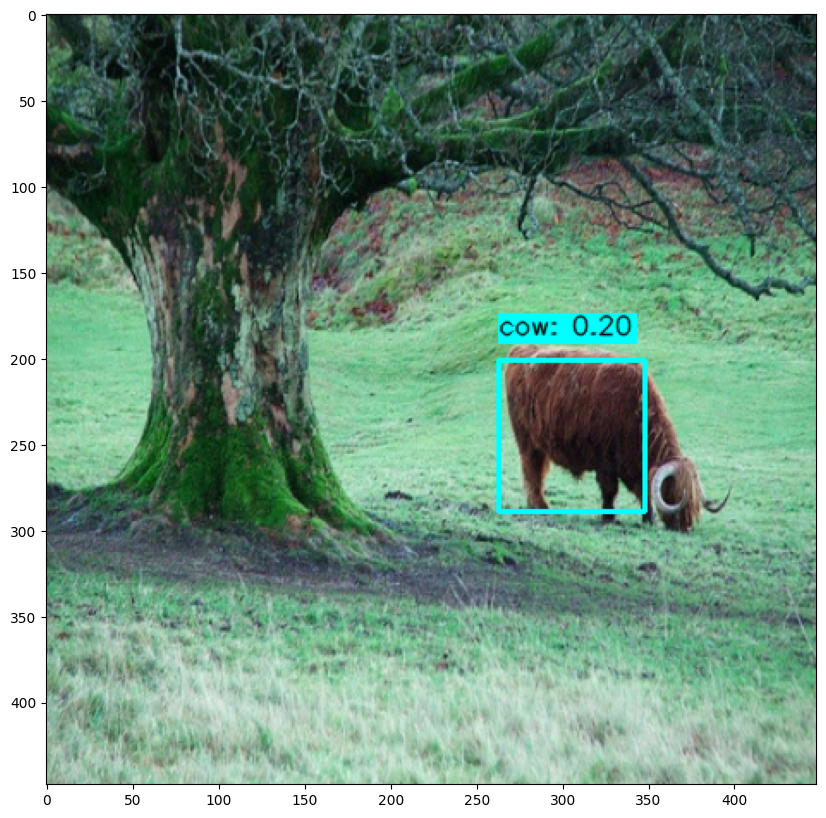

In [32]:
%matplotlib inline
import matplotlib.pyplot as plt
import cv2

# 這邊也有改，要能夠畫出多個 bounding box
np_img = cv2.imread('./VOCdevkit_test/VOC2007/JPEGImages/000013.jpg')
resized_img = cv2.resize(np_img, (IMAGE_SIZE, IMAGE_SIZE))
np_img = cv2.cvtColor(resized_img, cv2.COLOR_BGR2RGB)
resized_img = np_img.copy() 
np_img = np_img.astype(np.float32)
np_img = np_img / 255.0 * 2 - 1
np_img = np.reshape(np_img, (1, IMAGE_SIZE, IMAGE_SIZE, 3))

y_pred = YOLO(np_img, training=False)

boxes, scores, classes = process_outputs(y_pred, conf_threshold=0.06, iou_threshold=0.3)

print(f"Detected {len(boxes)} objects:")

for i in range(len(boxes)):
    xmin, ymin, xmax, ymax = map(int, boxes[i])
    class_num = int(classes[i])
    conf = scores[i]
    class_name = classes_name[class_num]
    
    print(f"- {class_name} (Confidence: {conf:.2f}) at [{xmin}, {ymin}, {xmax}, {ymax}]")
    
    cv2.rectangle(resized_img, (xmin, ymin), (xmax, ymax), (0, 255, 255), 2)
    
    label = f"{class_name}: {conf:.2f}"
    (w, h), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 2)
    
    text_ymin = ymin - 10
    if text_ymin < h:
        text_ymin = ymin + h + 10
        
    cv2.rectangle(resized_img, (xmin, text_ymin - h - 5), (xmin + w, text_ymin), (0, 255, 255), -1) # 文字背景
    cv2.putText(resized_img, label, (xmin, text_ymin - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 0), 1, cv2.LINE_AA) # 文字

plt.figure(figsize=(10, 10))
plt.imshow(resized_img)
plt.show()

## Report

### 1. Model Architecture

在這次競賽中，我們實現一個 **YOLOv1** 框架的物件偵測模型。由於時間限制以及更換框架要大幅修改整體架構，我們決定專注於優化 YOLOv1。

我們的模型架構包含兩個部分：

1.  **Feature Extractor:**
    
    我們用 Transfer Learning 的方式，使用在 ImageNet 上預訓練好的 `DenseNet121` 作為 feature extractor。
    * 我們最初嘗試了 **VGG19**，但最後選擇了 **DenseNet121** 作為我們的主要模型，因為它表現更佳且參數更少
    * 我們載入 **DenseNet121** 的預訓練權重，並進行部分微調：

2.  **Detection Head:**
    
    `DenseNet121` feature map 之後，接上了自定義的 `conv_leaky_relu` CNN Layer，進一步處理特徵並轉成 YOLO 格式輸出。

---

### 2. Experiments and Results

我們針對 Data Imbalance、Data Augmentation 以及 Output Processing 三個方面進行了多組實驗

#### Data Imbalance

1. 首先用 `check_imbalance` 分析給定的 PASCAL VOC Training dataset。結果顯示（如 `check_imbalance` 的輸出圖所示），**`person`** 類別的 instance 數量遠遠超過其他類別，而許多類別（如 `boat`, `sofa`, `diningtable`）的樣本數非常少。
2. 這種不平衡會導致模型嚴重 bias `person` 類別。對此我們實作了 `create_oversampled_dataset` 函式。
3. 此函式會 oversample 那些包含**稀有類別**的圖片，直到所有類別的 instance 數都達到我們設定的閾值，藉此做到真正的類別平衡。

#### Data Augmentation

在均衡後的資料集基礎上，我們進行了多組 Data Augmentation 實驗，以評估不同增強策略對模型表現的影響

1. 僅使用 `augment_with_tf` 函式進行 offline 增強
    * 隨機 **水平翻轉** 和 **Color Jitter**（亮度、對比、飽和度、色相）。
    * **Kaggle Score: 0.31**

2. 額外加入了**Rotation**、**Shear**、**Scale**。
   * **Kaggle Score:** 0.44

3.  使用翻轉、色彩，加上 **Mosaic 增強**。
    * 將四張圖拼接成一張，並調整 Bounding Box 標註
    * **Kaggle Score:** 0.93

我們的增強策略分析顯示，最簡單的組合（組 1，0.31）效果最佳，因為水平翻轉和 Color Jitter 能在不破壞物體結構或標註準確性的前提下，增加資料多樣性，對 YOLOv1 這種經典架構最為友好

相反地，更複雜的增強反而有負面影響：像是組 2（0.44）的旋轉和錯切就導致了標註失真，猜測是因為 bbox 為了容納傾斜的物體，標註框必須擴大，反而導致框內包含了大量的 background noise，或是無法緊密包覆物體

而組 3（0.93）的 Mosaic 增強效果最差，可能跟 YOLOv1 架構的缺陷有關：
1. 模型本身不擅長偵測小物件， Mosaic 會產生大量縮小的小物件，導致模型沒辦法有效學習 
2. Mosaic 會讓多個物件中心點落在同一個 grid cell 中，違反 YOLOv1 每個 grid cell 只負責一個物件的機制，因此我們認為 Mosaic 增強跟 YOLOv1 是不相容的

#### Output Processing

* 原始的 `process_outputs` 處理邏輯較為簡單，一次只能預測一個物件。我們把它改成結合 **Non-Max Suppression (NMS)** 的版本，能在一張圖上偵測多個物件
* **NMS:** 此允許模型在所有 98 個候選框中，找出所有信心分數高於 `conf_threshold` 的框，然後 NMS 會根據 `iou_threshold` 移除重疊的框，最終在一張圖上輸出**多個**偵測物件
* 我們發現，將 `CONF_THRESHOLD` 設為一個極低的值（0.0），並讓 NMS 函式（`IOU_THRESHOLD = 0.3`）去處理大量的候選框，在 Kaggle 上獲得了最高分數。這可能跟這個比賽的評分標準有關，因為評分是基於所有預測框的 mAP，而非單一最高分框

---

### 3. Problems and Solutions

#### Transfer Learning

* **Problem:**
    一開始，我們嘗試將整個 `DenseNet121` 預訓練模型設為可訓練 (`base_model.trainable = True`) 進行 fine-tune，導致以下問題：
    1.  **VRAM 不夠用:** 在使用 `DenseNet121` 作為 feature extractor 時，參數量非常龐大，導致在訓練過程中 VRAM 消耗過高，需要使用較小的 batch size（像是 4 或 8）才能避免 OOM 錯誤，但這樣又會導致訓練不穩定，像是梯度爆炸
    2.  **訓練緩慢且效果不佳:** 訓練速度極慢，且反而破壞了 ImageNet 預訓練好的底層特徵

* **Solution:**
    我們採用了 **Partial Fine-tuning** 的方法，只微調 `DenseNet121` 的後幾層
    ```python
    # base_model.trainable = False
    for layer in base_model.layers[:-100]:
        layer.trainable = False
    for layer in base_model.layers[-100:]:
        layer.trainable = True
    ```
    我們只允許**最後 100 層**的權重進行更新，而將前面的層凍起來
    * 早期層學習到的是通用特徵，這些特徵在 ImageNet 和 PASCAL VOC 中是共通的。我們只需要微調後幾層，讓它們適應我們的特定任務即可
    * 這種方法減少了 VRAM 消耗，加快了訓練速度，並取得了比「完全 fine-tune」更好的模型效果

#### YOLOv1 Class Loss

* **Problem:**
    我們發現原本的 `class_loss` 計算方式可能有誤：
    ```python
    class_loss = tf.nn.l2_loss(tf.reshape(object_mask, ...) * (p_P - P))
    ```
    這樣會導致**所有**覆蓋在同一個物件上的 grid cells 都要去預測該物件的類別，但 YOLOv1 核心思想應該是「一個物件**只由**其中心點所在的那個 grid cell 負責預測」。如果強迫 bbox 覆蓋的所有 grid cells 都去預測同一個類別，可能讓模型學習困難

* **Solution:**
    我們將 `class_loss` 的計算修改為：
    `class_loss = tf.nn.l2_loss(tf.reshape(response, ...) * (p_P - P))`

    這裡的 `response` tensor 是一個「單點」mask，它**只在物件中心點所在的「那一個」網格上為 1**，其餘皆為 0。
    * 修改後，從 0.40 -> 0.31，顯著提升了模型在 Kaggle 上的表現